In [1]:
import cobra
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import hdbscan
from pathlib import Path
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [2]:
repo_folder = Path("../..")
gp_folder = repo_folder / 'data/1_growth_phenotyping'
figure_folder = repo_folder / "Figures" / "1_growth_phenotyping"


In [3]:
fn_selected = gp_folder / 'selected_carbon_sources.csv'
df_selected = pd.read_csv(fn_selected)

In [4]:
met_index_dict = df_selected.set_index('BiGG ID')['Metabolite name'].to_dict()


In [5]:
model_universe_fn = gp_folder / 'carveme_universe_bacteria.xml'
model_universe = cobra.io.read_sbml_model(model_universe_fn)

Set parameter Username
Academic license - for non-commercial use only - expires 2026-11-28


In [6]:
model_universe.optimize()
print(model_universe.summary())


Objective
1.0 Growth = 433.30021174478645

Uptake
------
    Metabolite          Reaction    Flux  C-Number C-Flux
    12ppd__R_e     EX_12ppd__R_e    1000         3  1.68%
      2ameph_e       EX_2ameph_e    1000         2  1.12%
       2obut_e        EX_2obut_e    1000         4  2.24%
         3mb_e          EX_3mb_e   195.2         5  0.55%
       4abut_e        EX_4abut_e    1000         4  2.24%
      4hphac_e       EX_4hphac_e    1000         8  4.47%
LalaDgluMdap_e EX_LalaDgluMdap_e   43.33        15  0.36%
       acnam_e        EX_acnam_e    1000        11  6.15%
     actn__R_e      EX_actn__R_e   283.8         4  0.63%
         akg_e          EX_akg_e    1000         5  2.79%
         amp_e          EX_amp_e   88.18        10  0.49%
        argp_e         EX_argp_e    1000         6  3.35%
      asn__L_e       EX_asn__L_e   104.4         4  0.23%
         ca2_e          EX_ca2_e   2.255         0  0.00%
         cit_e          EX_cit_e  0.2994         6  0.00%
     citr__L_e 

In [7]:
for r in model_universe.exchanges:
    r.lower_bound = 0
    # m,i = r.metabolites.popitem()
    # if 'C' in m.formula:
    #     r.lower_bound = 0
    #     sol = model.slim_optimize()
    #     if sol == 0:
    #         print(r.id, sol)

In [8]:
# M9
uptake = ['EX_glc__D_e', 'EX_nh4_e', 'EX_pi_e', 'EX_so4_e', 'EX_h2o_e', 'EX_h_e', 'EX_o2_e', 'EX_fe2_e', 'EX_fe3_e', 'EX_cobalt2_e', 'EX_ca2_e', 'EX_cl_e', 
       'EX_cu2_e','EX_k_e', 'EX_mg2_e', 'EX_mn2_e','EX_zn2_e', 'EX_mobd_e', 'EX_ni2_e', 'EX_na1_e']


model_universe.add_boundary(model_universe.metabolites.na1_e, 'exchange', lb = -1000, ub = 1000)
model_universe.add_boundary(model_universe.metabolites.ni2_e, 'exchange', lb = -1000, ub = 1000)
for r_id in uptake:
    model_universe.reactions.get_by_id(r_id).lower_bound = -1000
print(model_universe.optimize())

<Solution 64.600 at 0x16db93d60>


In [9]:
carbon_compounds = []
model_universe.reactions.EX_glc__D_e.lower_bound = 0
for r in model_universe.exchanges:
    with model_universe as model:
        model.reactions.get_by_id(r.id).bounds = (-10,1000)
        sol = model.slim_optimize()
        if sol > 0:
            carbon_compounds.append(r.id)

In [10]:
Nc = len(carbon_compounds)
fluxes = np.zeros((Nc, len(model_universe.reactions)))
for i in range(Nc):
    with model_universe as model:
        r_id = carbon_compounds[i]
        model.reactions.get_by_id(r_id).bounds = (-10,1000)
        solution = cobra.flux_analysis.pfba(model)
        fluxes[i,:] = solution.fluxes

# Cluster fluxes

In [11]:
from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
# from sklearn.cluster import DBSCAN
# import scipy.cluster.hierarchy as spc


In [12]:
nz_fluxes = fluxes[:, ~(fluxes==0).all(axis =0)]

In [13]:
nz_fluxes.shape

(509, 2812)

In [14]:
binary_fluxes = np.sign(nz_fluxes)
bf2 = binary_fluxes[:, ~(binary_fluxes.std(axis =0) == 0)]

In [15]:
pca = PCA(n_components=2)
t = pca.fit_transform(bf2)


In [16]:
t_df = pd.DataFrame(t, columns = ['PC1', 'PC2'])
t_df['Exchange'] = carbon_compounds
for i, row in t_df.iterrows():
    exch = row['Exchange']
    met_name = met_index_dict.get(exch[3:-2], None)
    t_df.at[i, 'Metabolite name'] = met_name

In [17]:
clusterer = hdbscan.HDBSCAN(min_samples=2, min_cluster_size=10, cluster_selection_epsilon = 0.4)
clusterer.fit(t)
t_df['Cluster'] = clusterer.labels_

palette = sns.color_palette('tab10', n_colors = len(t_df['Cluster'].unique())-1)
palette = [(0.8, 0.8, 0.8)] + palette # grey for noise
hue_order = np.sort(t_df['Cluster'].unique())
pca.explained_variance_

/Users/snorre/miniconda3/envs/reframed/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snorre/miniconda3/envs/reframed/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([10.52339883,  7.34105092])

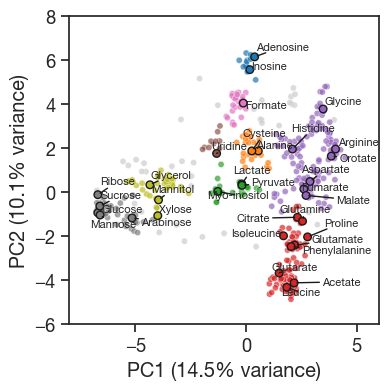

In [18]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize = (4, 4))
sel_idx = t_df['Metabolite name'].notnull()
sns.scatterplot(data = t_df.loc[~sel_idx], x = 'PC1', y = 'PC2', hue = 'Cluster', 
                hue_order = hue_order, palette = palette, ax = ax, alpha = 0.7, legend = False, s = 20)
sns.scatterplot(data = t_df.loc[sel_idx], x = 'PC1', y = 'PC2', hue = 'Cluster', 
                hue_order = hue_order, palette = palette, ax = ax, alpha = 1, legend = False, s = 30, edgecolor = 'k', lw = 1)

# Annotate metabolite names using adjustText
texts = []
for _, row in t_df.loc[sel_idx].iterrows():
    texts.append(ax.text(row['PC1'], row['PC2'], row['Metabolite name'], fontsize=8, ha='left', va='bottom'))
plt.xlim(-8, 6)
plt.ylim(-6, 8)

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='k'))#, expand_points=(1.2, 1.2))
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.savefig(gp_folder / 'carbon_source_pca_clusters.pdf', dpi = 300, bbox_inches = 'tight')
plt.show()


# TSNE

/Users/snorre/miniconda3/envs/reframed/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snorre/miniconda3/envs/reframed/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snorre/miniconda3/envs/reframed/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/snorre/miniconda3/envs/reframed/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_91667/3009003037.py:21: UserWarning: 
The palette lis

Text(1.7763568394002505e-15, 0.5, 'tSNE 2')

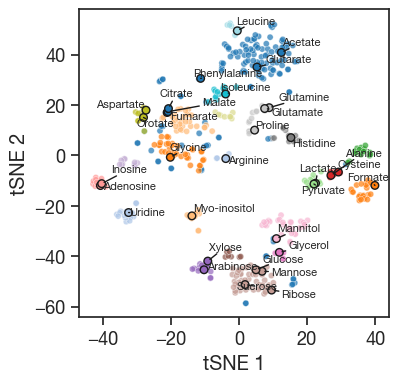

In [19]:
X_embedded = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=15).fit_transform(bf2)
# clustering = DBSCAN(eps=2, min_samples=2 ).fit(X_embedded)
tsne_clust = hdbscan.HDBSCAN()
tsne_clust.fit(X_embedded)

t_df['TSNE 1'] = X_embedded[:,0]
t_df['TSNE 2'] = X_embedded[:,1]

clusterer = hdbscan.HDBSCAN()#min_samples=2, min_cluster_size=10, cluster_selection_epsilon = 0.4)
clusterer.fit(X_embedded)
t_df['Cluster TSNE'] = clusterer.labels_
t_df.sort_values(by='Cluster TSNE', inplace = True)
palette = sns.color_palette('tab20', n_colors = len(t_df['Cluster TSNE'].unique())-1)
# palette = [(0.8, 0.8, 0.8)] + palette # grey for noise
hue_order = np.sort(t_df['Cluster TSNE'].unique())

fig, ax = plt.subplots(figsize = (4, 4))
sel_idx = t_df['Metabolite name'].notnull()
sns.scatterplot(data = t_df.loc[~sel_idx], x = 'TSNE 1', y = 'TSNE 2', hue = 'Cluster TSNE', 
                hue_order = hue_order, palette = 'tab20', ax = ax, alpha = 0.7, legend = False, s = 20)
sns.scatterplot(data = t_df.loc[sel_idx], x = 'TSNE 1', y = 'TSNE 2', hue = 'Cluster TSNE', 
                hue_order = hue_order, palette = palette, ax = ax, alpha = 1, legend = False, s = 30, edgecolor = 'k', lw = 1)

texts = []
for _, row in t_df.loc[sel_idx].iterrows():
    texts.append(ax.text(row['TSNE 1'], row['TSNE 2'], row['Metabolite name'], fontsize=8, ha='left', va='bottom'))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='k'))#, expand_points=(1.2, 1.2))
        
plt.xlabel('tSNE 1')
plt.ylabel('tSNE 2')

In [20]:
# df = pd.DataFrame()
# df['Exchange'] = carbon_compounds
# # df['PCA cluster'] = clusterer.labels_
# # df['tSNE cluster'] = tsne_clust.labels_
# df['Metabolite'] = metabolites
# df['Metabolite ID'] = metabolite_ids
# df.to_csv('Carbon_compounds_clustered.csv')